# **1. Understanding the Problem**

* **제목**: ISIC 2024 - Skin Cancer Detection with 3D-TBP  

* **미션**: 3D Total Body Photography (TBP)로부터 얻은 피부 병변 이미지를 사용하여, 악성 피부 병변을 식별하는 이진분류 알고리즘 개발.  

* **문제 유형**: 이진분류  

* **평가 지표**: pAUC (partial Area Under the ROC Curve) above 80% True Positive Rate (TPR). 점수는 0.0에서 0.2 사이의 범위를 가짐.

# **2. EDA**

## **2-1. 데이터셋 이해**

- **데이터 구성:**
    - **이미지 데이터:** JPEG 형식으로 제공되는 피부 병변 이미지.
    - **메타 데이터:** 이미지와 관련된 binary diagnostic label (악성/양성) 및 기타 입력 변수(예: age_approx, sex, anatom_site_general 등).  
    
    
- **데이터셋의 주요 특징:**
    - 3D TBP에서 추출된 병변 이미지로 구성되어 있으며, 이 이미지들은 비전문 환경에서도 사용될 수 있도록 휴대폰 사진과 유사한 품질을 가짐.
    - 각 병변은 15x15 mm의 필드 뷰로 잘린 이미지로 제공.
    - **데이터 불균형:** 악성 병변과 양성 병변 간의 분포를 이해하는 게 중요.

## **2-2. 데이터 구조 탐색**  

- **파일별 용도 파악:**
    - **train-image/**: 학습용 이미지 파일들이 저장된 폴더.
    - **train-image.hdf5**: 학습 데이터가 포함된 단일 hdf5 파일, 각 이미지의 고유 ID를 키로 사용.
    - **train-metadata.csv**: 학습용 데이터의 메타데이터가 포함된 CSV 파일.
    - **test-image.hdf5**: 테스트 이미지 데이터가 포함된 hdf5 파일로, 평가용 데이터셋.
    - **test-metadata.csv**: 테스트 데이터의 메타데이터가 포함된 CSV 파일.
    - **sample_submission.csv**: 올바른 형식으로 제출 파일의 샘플을 제공.  
    
    
- **피처 이해(이름, 의미 등):**
    - **`target`**: 이진 진단 라벨 (0: 양성, 1: 악성).
    - **`isic_id`**: 각 케이스에 대한 고유 식별자.
    - **`lesion_id`**: 관심 병변으로 수동 태그된 병변의 고유 식별자.
    - **`age_approx`, `sex`, `anatom_site_general`**: 환자의 나이, 성별, 병변 위치 등의 환자 메타데이터.
    - **`tbp_lv_`**로 시작하는 여러 피처: 병변의 색상, 경계, 위치 등 다양한 특성을 나타내는 값들.
    - 이외에도 병변의 크기, 비대칭성, 경계 등의 다양한 특성을 설명하는 다수의 피처가 포함됨.  
    
    
- **타깃 값: 제출(예측)해야 하는 값:**
    - 타깃 값은 각 이미지에 대해 해당 병변이 악성일 확률을 나타내는 0과 1 사이의 값(연속형)으로 예측해야 함.
    - 예측 결과는 `isic_id, target` 형식으로 제출하며, `target`은 병변이 악성일 확률을 나타내는 값임.

## **2-3. 데이터 시각화**

### **이미지 데이터 시각화**

In [1]:
class PATHS:
    train_images_h5_path = "/kaggle/input/isic-2024-challenge/train-image.hdf5"
    test_images_h5_path = "/kaggle/input/isic-2024-challenge/test-image.hdf5"
    
    train_metadata_path = "/kaggle/input/isic-2024-challenge/train-metadata.csv"
    test_metadata_path = "/kaggle/input/isic-2024-challenge/test-metadata.csv"
    
    submission_path = "/kaggle/input/isic-2024-challenge/sample_submission.csv"

In [2]:
import numpy as np
import pandas as pd
import io
import h5py
import tqdm
from PIL import Image

def read_images_from_hdf5(file_path):
    with h5py.File(file_path, 'r') as file:
        ids_list = list(file.keys())        
        ids_images = {} #dictionary
        for img_id in tqdm.tqdm(ids_list):
            image_data = file[img_id][()]
            image = Image.open(io.BytesIO(image_data))
            ids_images[img_id] = np.array(image)
    return ids_images

In [3]:
%%time
images_train = read_images_from_hdf5(PATHS.train_images_h5_path)
images_test = read_images_from_hdf5(PATHS.test_images_h5_path)

100%|██████████| 3/3 [00:00<00:00, 94.81it/s]

CPU times: user 4min 55s, sys: 32 s, total: 5min 27s
Wall time: 6min 33s


In [4]:
imgs_sizes = [img.shape for img in images_train.values()]

Text(0.5, 1.0, 'train_image_size_width')

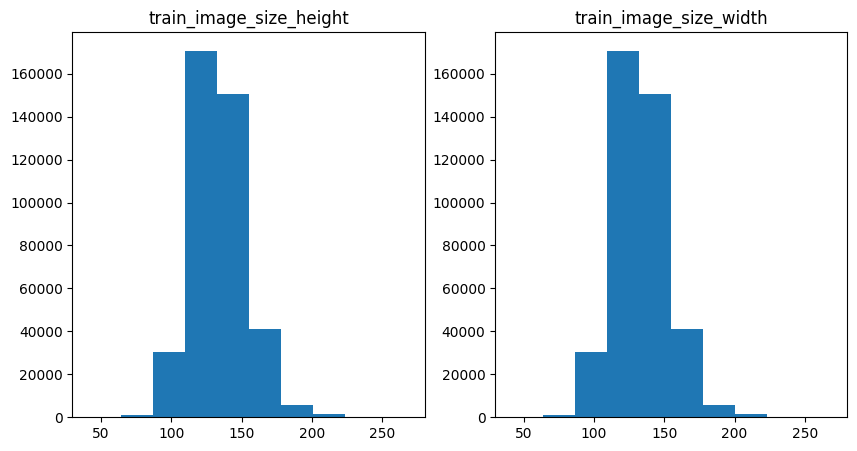

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

#height
axs[0].hist([i[0] for i in imgs_sizes])
axs[0].set_title("train_image_size_height")
#width
axs[1].hist([i[1] for i in imgs_sizes])
axs[1].set_title("train_image_size_width")

In [6]:
print(f"Min height within train images = {np.min([i[0] for i in imgs_sizes])}, Max height within train images = {np.max([i[0] for i in imgs_sizes])}")
print(f"Min width within train images = {np.min([i[1] for i in imgs_sizes])}, Max width within train images = {np.max([i[1] for i in imgs_sizes])}")
print(f"Height and width among images are equal = {[i[1] for i in imgs_sizes] == [i[0] for i in imgs_sizes]}")

Min height within train images = 41, Max height within train images = 269
Min width within train images = 41, Max width within train images = 269
Height and width among images are equal = True


-> 이미지마다 넓이와 높이 픽셀 크기가 다르다.

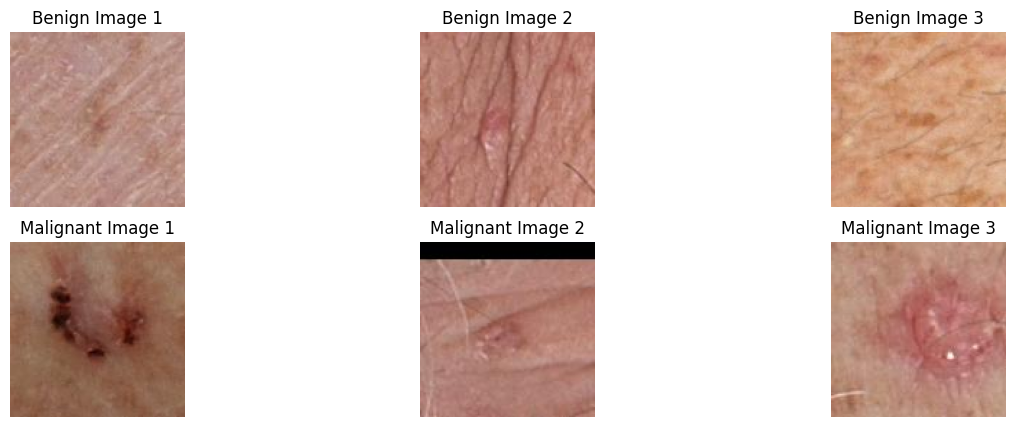

In [7]:
# 메타데이터 불러오기
train_metadata = pd.read_csv(PATHS.train_metadata_path, low_memory=False)

# 양성(benign) 이미지와 악성(malignant) 이미지의 ID를 분리
benign_images = train_metadata[train_metadata['target'] == 0]['isic_id'].values[:3]
malignant_images = train_metadata[train_metadata['target'] == 1]['isic_id'].values[:3]

# HDF5 파일에서 이미지 불러오기
train_images_file = '/kaggle/input/isic-2024-challenge/train-image.hdf5'
with h5py.File(train_images_file, 'r') as f:
    # 3개의 양성 이미지 시각화
    plt.figure(figsize=(15, 5))
    for i, image_id in enumerate(benign_images):
        example_image_data = f[image_id][()]
        image = Image.open(io.BytesIO(example_image_data))
        
        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(f'Benign Image {i+1}')
        plt.axis('off')
    
    # 3개의 악성 이미지 시각화
    for i, image_id in enumerate(malignant_images):
        example_image_data = f[image_id][()]
        image = Image.open(io.BytesIO(example_image_data))
        
        plt.subplot(2, 3, i + 4)
        plt.imshow(image)
        plt.title(f'Malignant Image {i+1}')
        plt.axis('off')

    plt.show()

### **메타 데이터 시각화**

In [8]:
import seaborn as sns
import pandas as pd

# 메타데이터 불러오기
train_metadata = pd.read_csv(PATHS.train_metadata_path, low_memory=False)

# 전체 메타 데이터 수
total_metadata_count = train_metadata.shape[0]

# 양성(benign) 데이터 수
benign_metadata_count = train_metadata[train_metadata['target'] == 0].shape[0]

# 악성(malignant) 데이터 수
malignant_metadata_count = train_metadata[train_metadata['target'] == 1].shape[0]

# 결과 출력
print(f"전체 메타 데이터 수: {total_metadata_count}")
print(f"양성 데이터 수: {benign_metadata_count}")
print(f"악성 데이터 수: {malignant_metadata_count}")

전체 메타 데이터 수: 401059
양성 데이터 수: 400666
악성 데이터 수: 393


In [9]:
train_metadata.shape

(401059, 55)

In [10]:
train_metadata.describe()

,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,...,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
count,401059.000000,398261.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,...,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,401059.000000,63.000000,4.010590e+05
mean,0.000980,58.012986,3.930827,19.974007,14.919247,28.281706,26.913015,34.786341,30.921279,54.653689,...,1.016459,2.715190,2.238605,0.306823,86.332073,-3.091862,1039.598221,55.823389,0.670952,9.716220e+01
std,0.031288,13.596165,1.743068,3.999489,3.529384,5.278676,4.482994,5.708469,4.829345,5.520849,...,0.734631,1.738165,0.623884,0.125038,52.559511,197.257995,409.819653,87.968245,0.792798,8.995782e+00
min,0.000000,5.000000,1.000000,-2.487115,-9.080269,-0.730989,9.237066,3.054228,11.846520,-1.574164,...,0.000000,0.268160,0.636247,0.052034,0.000000,-624.870728,-1052.134000,-291.890442,0.200000,1.261082e-16
25%,0.000000,50.000000,2.840000,17.330821,12.469740,24.704372,23.848125,31.003148,27.658285,51.566273,...,0.563891,1.456570,1.834745,0.211429,40.000000,-147.022125,746.519673,-8.962647,0.300000,9.966882e+01
50%,0.000000,60.000000,3.370000,19.801910,14.713930,28.171570,26.701704,34.822580,30.804893,55.035632,...,0.902281,2.186693,2.149758,0.282297,90.000000,-5.747253,1172.803000,67.957947,0.400000,9.999459e+01
75%,0.000000,70.000000,4.380000,22.304628,17.137175,31.637429,29.679913,38.430298,33.963868,58.298184,...,1.334523,3.474565,2.531443,0.382022,130.000000,140.474835,1342.131540,126.611567,0.600000,9.999996e+01
max,1.000000,85.000000,28.400000,48.189610,37.021680,54.306900,48.372700,58.765170,54.305290,105.875784,...,11.491140,17.563650,25.534791,0.977055,175.000000,614.471700,1887.766846,319.407000,5.000000,1.000000e+02


In [11]:
train_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401059 entries, 0 to 401058
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       401059 non-null  object 
 1   target                        401059 non-null  int64  
 2   patient_id                    401059 non-null  object 
 3   age_approx                    398261 non-null  float64
 4   sex                           389542 non-null  object 
 5   anatom_site_general           395303 non-null  object 
 6   clin_size_long_diam_mm        401059 non-null  float64
 7   image_type                    401059 non-null  object 
 8   tbp_tile_type                 401059 non-null  object 
 9   tbp_lv_A                      401059 non-null  float64
 10  tbp_lv_Aext                   401059 non-null  float64
 11  tbp_lv_B                      401059 non-null  float64
 12  tbp_lv_Bext                   401059 non-nul

In [12]:
# 수치형 데이터만 선택
numeric_columns = train_metadata.select_dtypes(include=['float64', 'int64']).columns

# 이상치 탐지 결과를 저장할 리스트
outliers = {}

print("각 컬럼에서 발견된 이상치 개수")
# IQR 방법을 사용하여 이상치 탐지
for col in numeric_columns:
    Q1 = train_metadata[col].quantile(0.25)
    Q3 = train_metadata[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # IQR 범위를 벗어나는 값을 이상치로 간주
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 탐지
    outlier_indices = train_metadata[(train_metadata[col] < lower_bound) | (train_metadata[col] > upper_bound)].index
    outliers[col] = outlier_indices

    print(f"{col} : {len(outlier_indices)}")
#     print(f"이상치 인덱스: {list(outlier_indices)}\n")

# 이상치 결과를 확인할 수 있는 사전 (Dictionary)
# print(outliers)

각 컬럼에서 발견된 이상치 개수
target : 393
age_approx : 645
clin_size_long_diam_mm : 27365
tbp_lv_A : 8057
tbp_lv_Aext : 4723
tbp_lv_B : 4474
tbp_lv_Bext : 5260
tbp_lv_C : 4766
tbp_lv_Cext : 4829
tbp_lv_H : 9822
tbp_lv_Hext : 2936
tbp_lv_L : 145
tbp_lv_Lext : 24
tbp_lv_areaMM2 : 36748
tbp_lv_area_perim_ratio : 21850
tbp_lv_color_std_mean : 15379
tbp_lv_deltaA : 12415
tbp_lv_deltaB : 8312
tbp_lv_deltaL : 11987
tbp_lv_deltaLB : 11574
tbp_lv_deltaLBnorm : 11975
tbp_lv_eccentricity : 6550
tbp_lv_minorAxisMM : 23297
tbp_lv_nevi_confidence : 0
tbp_lv_norm_border : 11900
tbp_lv_norm_color : 14793
tbp_lv_perimeterMM : 28808
tbp_lv_radial_color_std_max : 15987
tbp_lv_stdL : 17208
tbp_lv_stdLExt : 11116
tbp_lv_symm_2axis : 5815
tbp_lv_symm_2axis_angle : 0
tbp_lv_x : 45
tbp_lv_y : 470
tbp_lv_z : 352
mel_thick_mm : 8
tbp_lv_dnn_lesion_confidence : 80379


In [13]:
train_metadata.isnull().sum()

isic_id                              0
target                               0
patient_id                           0
age_approx                        2798
sex                              11517
anatom_site_general               5756
clin_size_long_diam_mm               0
image_type                           0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Lext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                        0
tbp_lv_deltaLB           

In [14]:
train_metadata.head(6)

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510
5,ISIC_0035502,0,IP_3026693,75.0,female,head/neck,2.54,TBP tile: close-up,3D: white,22.129183,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.619603


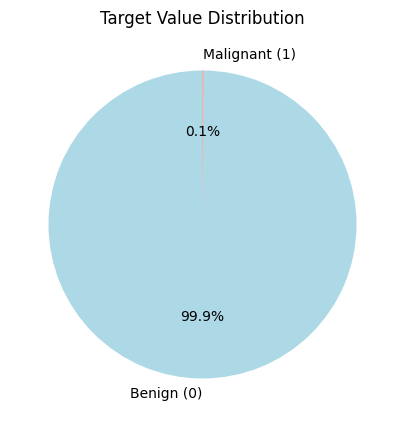

In [15]:
# 타깃 값 분포 계산
target_counts = train_metadata['target'].value_counts()

# 파이 차트 시각화
plt.figure(figsize=(5, 5))
plt.pie(target_counts, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
plt.title('Target Value Distribution')
plt.show()

-> 전체 데이터에서 악성 종양이 차지하는 비율이 **0.1%** 정도로 매우 작다.

In [16]:
# target과 특성 간의 관련 정도 시각화

from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# 숫자형 컬럼 자동 선택
target = train_metadata["target"]
numeric_col = train_metadata.select_dtypes(include=[np.number]).columns

# target 컬럼 제외
mu_train_data = train_metadata[numeric_col.drop(["target"])]
mu_train_data = mu_train_data.fillna(0)

# 상호 정보 계산
mu_info = mutual_info_classif(mu_train_data, target, random_state=42)
mu_df = pd.Series(mu_info)
mu_df.index = mu_train_data.columns
mu_info = pd.DataFrame(mu_df.sort_values(ascending=False), columns=["Numberic"])

# 시각화
mu_info.style.background_gradient("cool")

,Numberic
age_approx,0.010160
tbp_lv_dnn_lesion_confidence,0.003727
tbp_lv_symm_2axis_angle,0.002495
clin_size_long_diam_mm,0.001663
tbp_lv_areaMM2,0.001318
tbp_lv_perimeterMM,0.001281
tbp_lv_minorAxisMM,0.001137
mel_thick_mm,0.001087
tbp_lv_H,0.000802
tbp_lv_norm_color,0.000643


In [17]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 범주형 컬럼 자동 선택
categorical_col = train_metadata.select_dtypes(include=['object']).columns

# 특정 컬럼 제외
mu_train_data = train_metadata[categorical_col.drop(["isic_id", "patient_id"])]
mu_train_data = mu_train_data.fillna("NaN")

# 레이블 인코딩
encoder = LabelEncoder()
for col in mu_train_data.columns:
    mu_train_data[col] = encoder.fit_transform(mu_train_data[col])
    
# 상호 정보 계산
mu_info = mutual_info_classif(mu_train_data, target, random_state=42)
mu_df = pd.Series(mu_info)
mu_df.index = mu_train_data.columns
mu_info = pd.DataFrame(mu_df.sort_values(ascending=False), columns=["Numberic"])

# 시각화
mu_info.style.background_gradient("cool")

,Numberic
iddx_3,0.108948
iddx_5,0.108411
iddx_2,0.107697
iddx_4,0.077808
lesion_id,0.072255
mel_mitotic_index,0.071595
sex,0.055120
anatom_site_general,0.042318
copyright_license,0.042220
attribution,0.040446


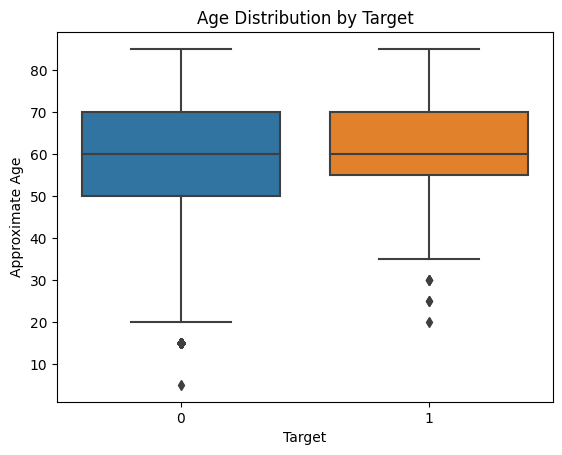

In [18]:
# 연속형 변수 (나이) 시각화 (박스플롯)
sns.boxplot(x='target', y='age_approx', data=train_metadata)
plt.title('Age Distribution by Target')
plt.xlabel('Target')
plt.ylabel('Approximate Age')
plt.show()

-> 악성 종양 환자들 중 **30세 미만인 환자는 거의 없다.**

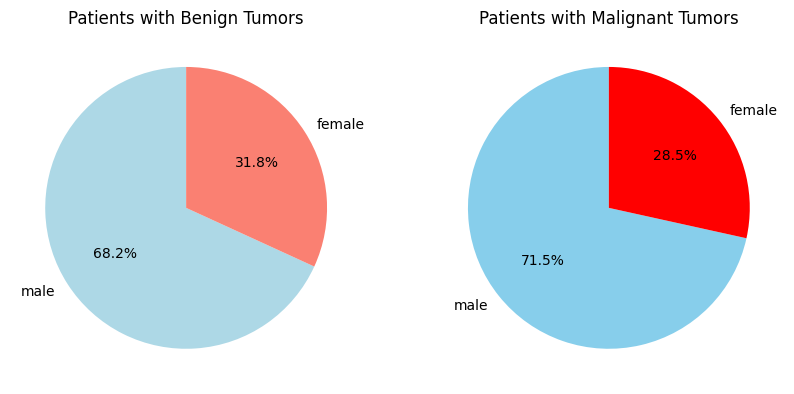

In [19]:
# 악성 종양(target == 1)과 양성 종양(target == 0)을 가진 데이터 필터링
malignant_data = train_metadata[train_metadata['target'] == 1]
benign_data = train_metadata[train_metadata['target'] == 0]

# 성별 비율 계산
malignant_sex_distribution = malignant_data['sex'].value_counts()
benign_sex_distribution = benign_data['sex'].value_counts()

# 파이 차트 시각화
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# 양성 종양 파이 차트
ax[0].pie(benign_sex_distribution, labels=benign_sex_distribution.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
ax[0].set_title('Patients with Benign Tumors')

# 악성 종양 파이 차트
ax[1].pie(malignant_sex_distribution, labels=malignant_sex_distribution.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'red'])
ax[1].set_title('Patients with Malignant Tumors')

plt.show()

-> **성별**의 차이에 따른 양성, 악성 종양의 **차이는 거의 없다.**

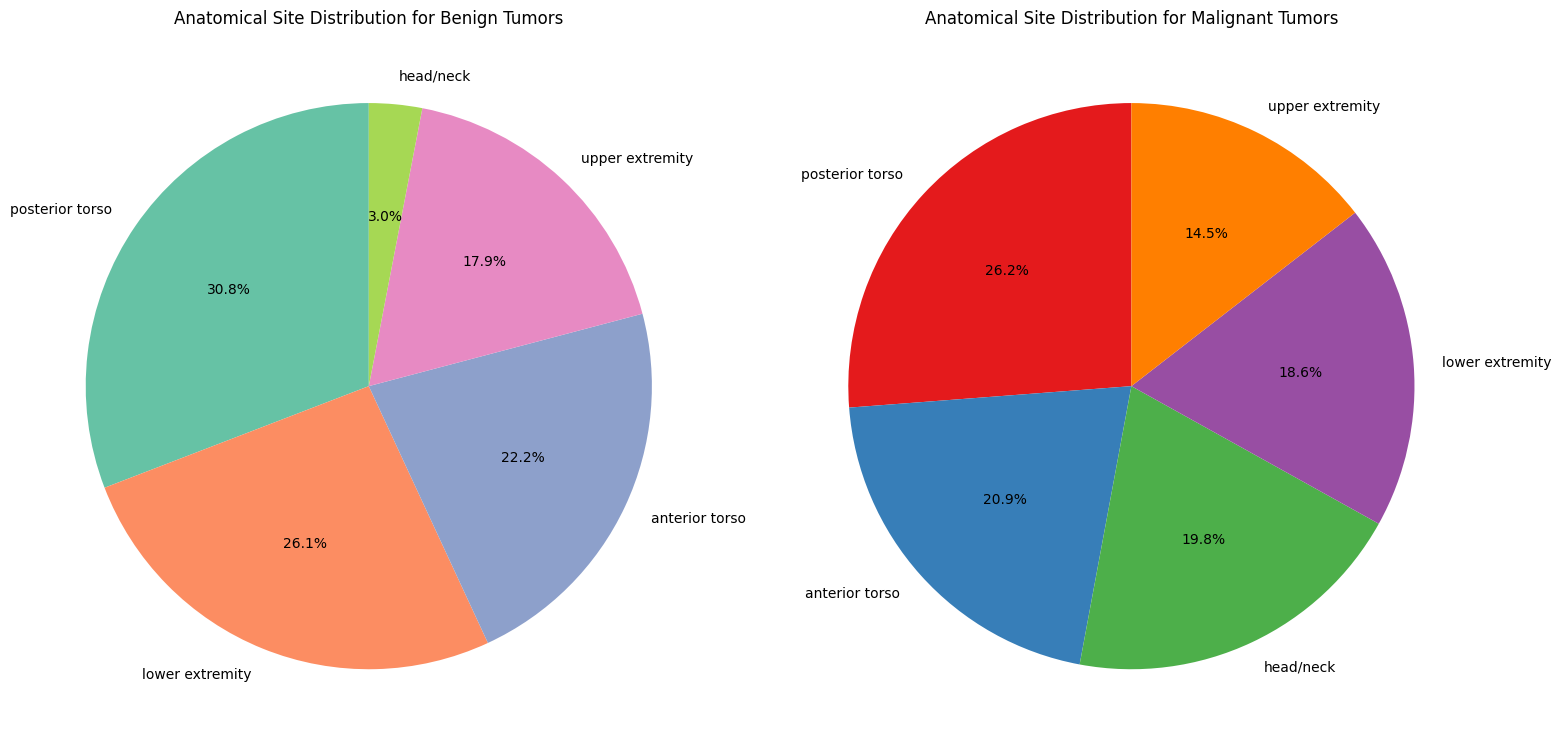

In [20]:
# 병변 위치별 분포 계산
benign_site_distribution = benign_data['anatom_site_general'].value_counts()
malignant_site_distribution = malignant_data['anatom_site_general'].value_counts()

# 파이 차트 시각화
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# 양성 종양에 대한 병변 위치 파이 차트
ax[0].pie(benign_site_distribution, labels=benign_site_distribution.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
ax[0].set_title('Anatomical Site Distribution for Benign Tumors')

# 악성 종양에 대한 병변 위치 파이 차트
ax[1].pie(malignant_site_distribution, labels=malignant_site_distribution.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set1.colors)
ax[1].set_title('Anatomical Site Distribution for Malignant Tumors')

plt.tight_layout()
plt.show()

-> 양성 중 **head/neck의 비율 0.3%**와 악성 중 **head/neck의 비율 19.8%** 차이가 가장 크다.

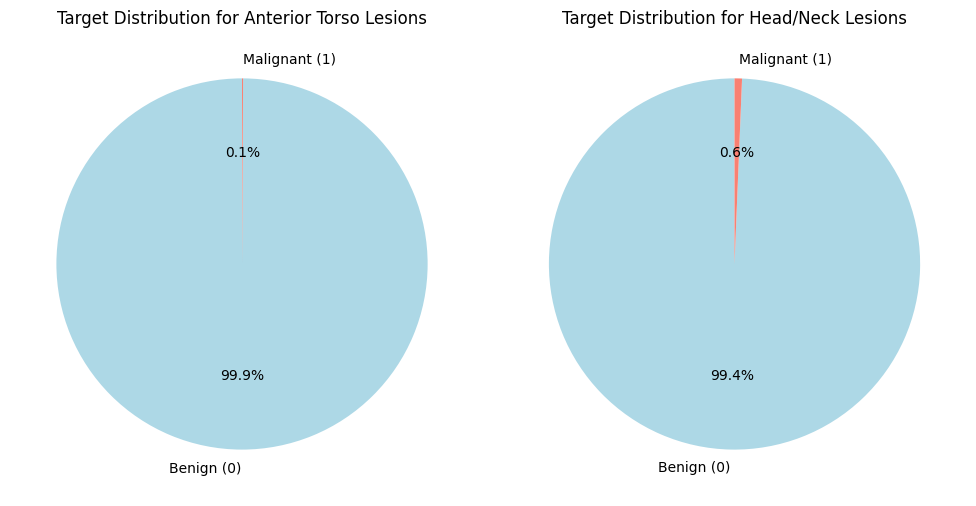

In [21]:
# 'anterior torso'와 'head/neck' 위치에 해당하는 데이터 필터링
anterior_torso_data = train_metadata[train_metadata['anatom_site_general'] == 'anterior torso']
head_neck_data = train_metadata[train_metadata['anatom_site_general'] == 'head/neck']

# 양성과 악성 종양 비율 계산
anterior_torso_distribution = anterior_torso_data['target'].value_counts()
head_neck_distribution = head_neck_data['target'].value_counts()

# 파이 차트 시각화
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# 'anterior torso'에 대한 파이 차트
ax[0].pie(anterior_torso_distribution, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
ax[0].set_title('Target Distribution for Anterior Torso Lesions')

# 'head/neck'에 대한 파이 차트
ax[1].pie(head_neck_distribution, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
ax[1].set_title('Target Distribution for Head/Neck Lesions')

plt.tight_layout()
plt.show()

-> 가장 차이가 적었던 **anterior torso**와 가장 차이가 컸던 **head/neck**에 대해 각각 악성 종양일 확률은 **6배** 차이난다.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


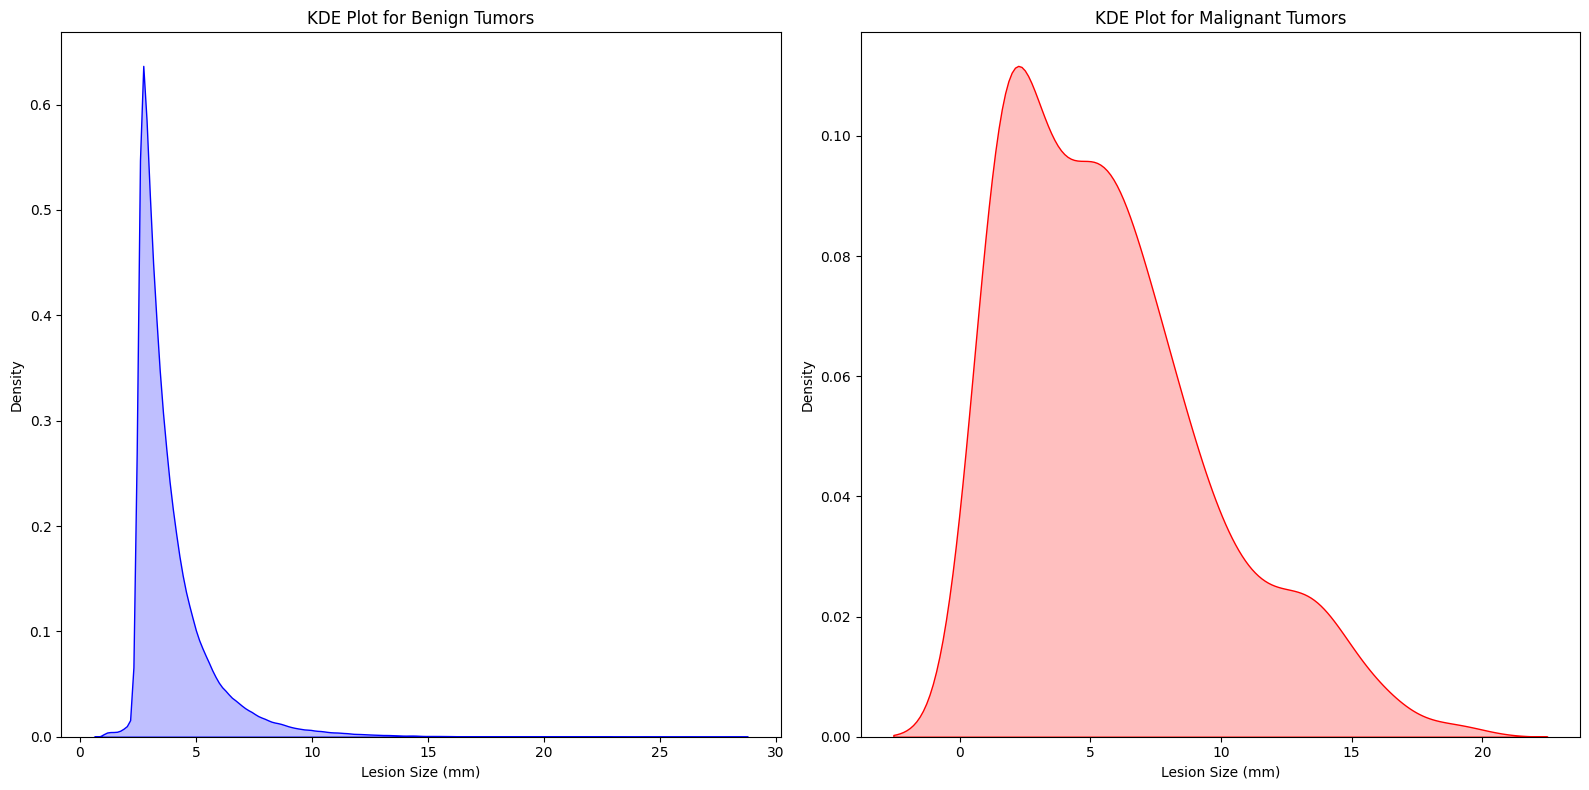

In [22]:
# KDE Plot 시각화
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# 양성 종양 KDE Plot
sns.kdeplot(data=benign_data, x='clin_size_long_diam_mm', fill=True, color='blue', ax=ax[0])
ax[0].set_title('KDE Plot for Benign Tumors')
ax[0].set_xlabel('Lesion Size (mm)')
ax[0].set_ylabel('Density')

# 악성 종양 KDE Plot
sns.kdeplot(data=malignant_data, x='clin_size_long_diam_mm', fill=True, color='red', ax=ax[1])
ax[1].set_title('KDE Plot for Malignant Tumors')
ax[1].set_xlabel('Lesion Size (mm)')
ax[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

-> 양성 종양의 경우 **10mm** 이상인 경우가 거의 없다.  
-> 악성 종양의 경우 **10mm** 이상인 경우도 많다.

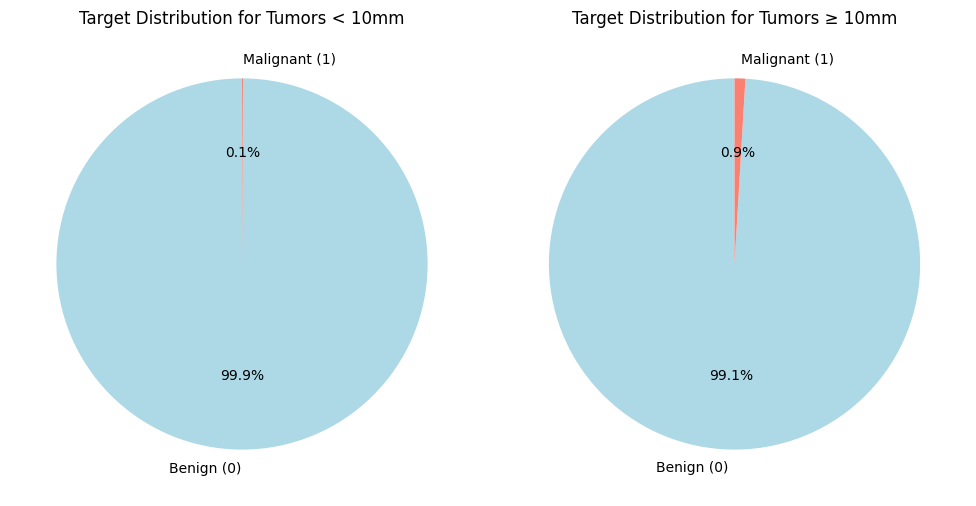

In [23]:
# 종양 크기 10mm 이상과 이하로 데이터 분리
size_above_10mm = train_metadata[train_metadata['clin_size_long_diam_mm'] >= 10]
size_below_10mm = train_metadata[train_metadata['clin_size_long_diam_mm'] < 10]

# 양성과 악성 종양 비율 계산
size_above_10mm_distribution = size_above_10mm['target'].value_counts()
size_below_10mm_distribution = size_below_10mm['target'].value_counts()

# 파이 차트 시각화
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# 10mm 이하 종양에 대한 파이 차트
ax[0].pie(size_below_10mm_distribution, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
ax[0].set_title('Target Distribution for Tumors < 10mm')

# 10mm 이상 종양에 대한 파이 차트
ax[1].pie(size_above_10mm_distribution, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
ax[1].set_title('Target Distribution for Tumors ≥ 10mm')

plt.tight_layout()
plt.show()

-> 종양의 크기가 **10mm 이상**인 경우가 이하인 경우보다 악성 종양일 확률이 **9배** 높다.

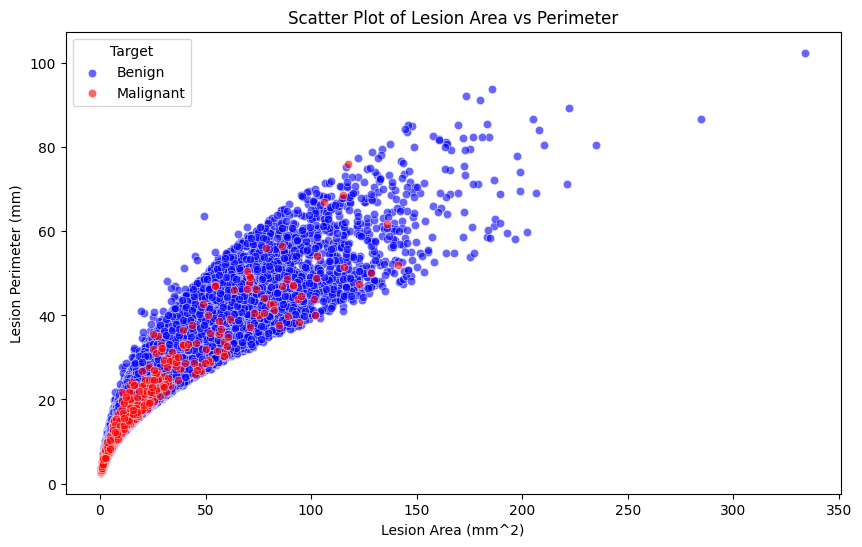

In [24]:
# 산점도 시각화: 병변 면적과 병변 둘레 간의 관계
plt.figure(figsize=(10, 6))

# 먼저 양성 종양을 그립니다
sns.scatterplot(data=benign_data, x='tbp_lv_areaMM2', y='tbp_lv_perimeterMM', color='blue', label='Benign', alpha=0.6)

# 그 위에 악성 종양을 그립니다
sns.scatterplot(data=malignant_data, x='tbp_lv_areaMM2', y='tbp_lv_perimeterMM', color='red', label='Malignant', alpha=0.6)

plt.title('Scatter Plot of Lesion Area vs Perimeter')
plt.xlabel('Lesion Area (mm^2)')
plt.ylabel('Lesion Perimeter (mm)')
plt.legend(title='Target')
plt.show()

-> 종양의 면적이 커질수록 둘레의 길이도 길어진다.

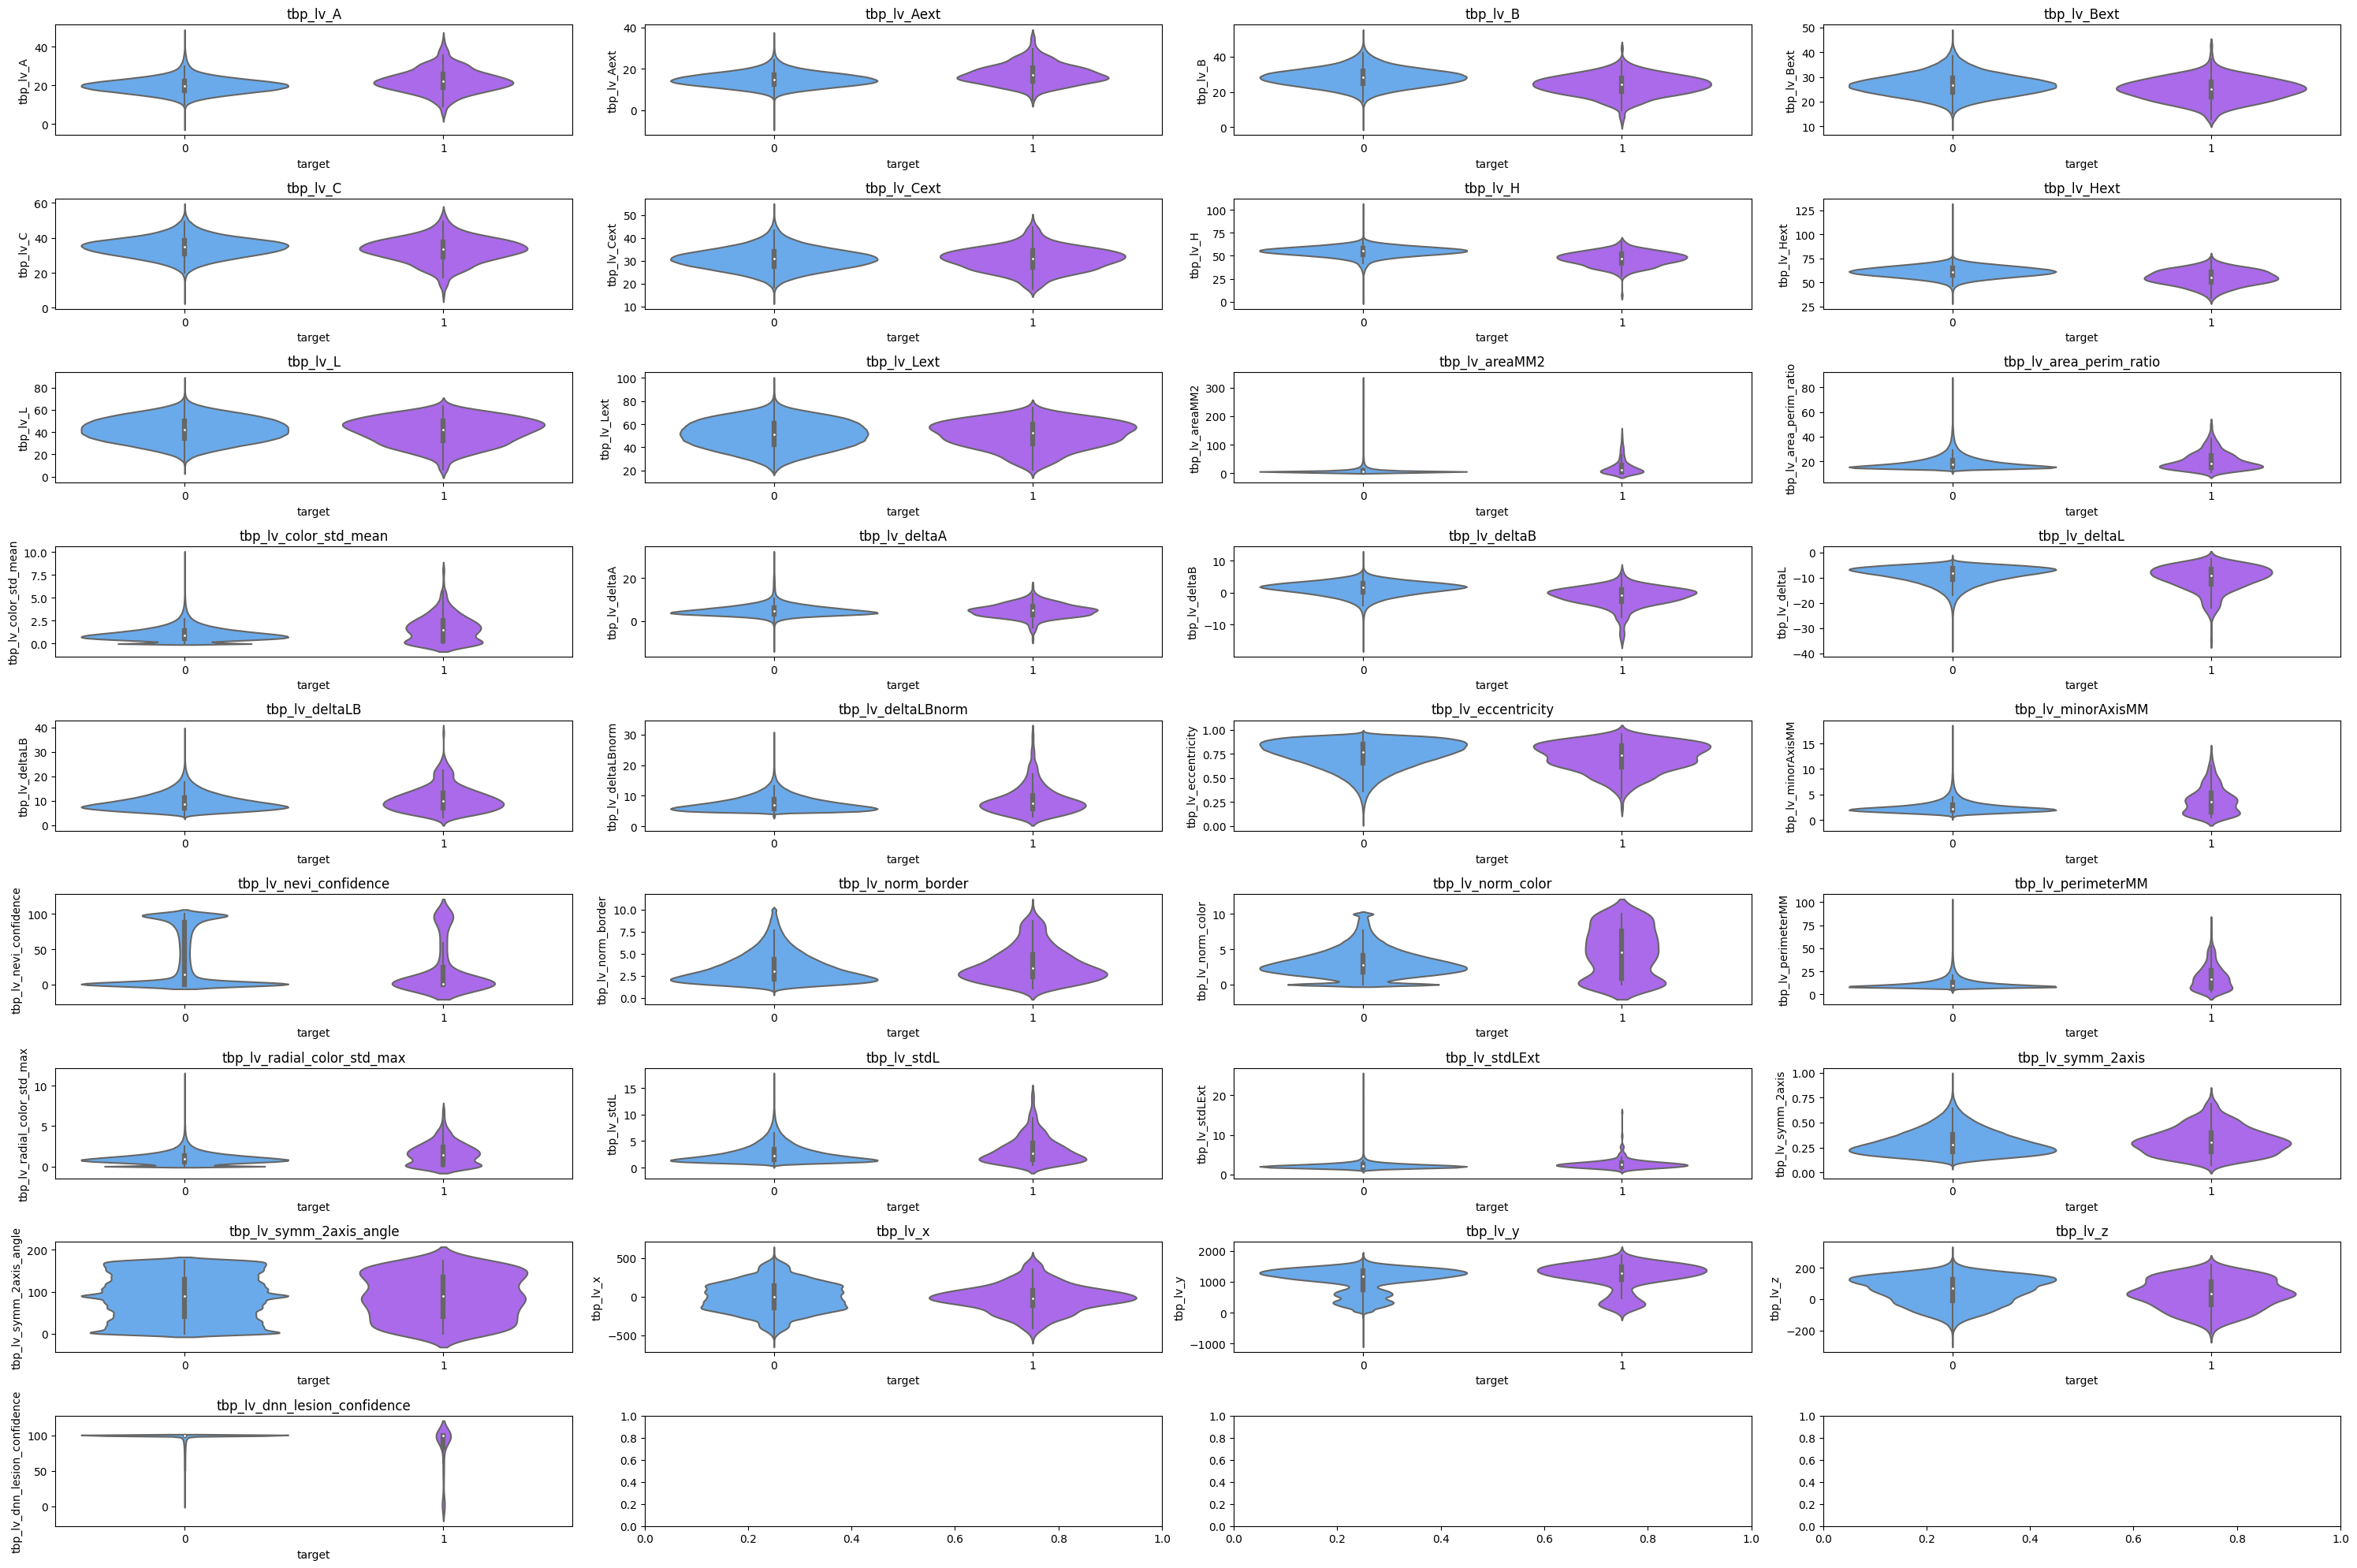

In [25]:
# Assuming 'target' is the categorical variable and 'tbp_lv_*' are numeric columns

# Filter tbp_lv columns from numeric columns
numeric_columns = train_metadata.select_dtypes(include=['number'])
tbp_lv_numeric_cols = [col for col in numeric_columns.columns if col.startswith('tbp_lv')]

# Create a figure with a suitable size 
fig, axes = plt.subplots(len(tbp_lv_numeric_cols) // 4 + 1, 4, figsize=(30, 20))  # Adjust figsize for better visualization

# Loop through tbp_lv numeric columns and create violin plots
for idx, col in enumerate(tbp_lv_numeric_cols):
    # Create a temporary DataFrame dropping missing values for current column and target
    df_temp = train_metadata[['target', col]].dropna()

    # Get row and column index for subplot placement
    row = idx // 4
    col_index = idx % 4

    sns.violinplot(x='target', y=col, data=df_temp, ax=axes[row, col_index], palette="cool")
    axes[row, col_index].set_title(col)  # Set title for each subplot

plt.tight_layout()
plt.show()

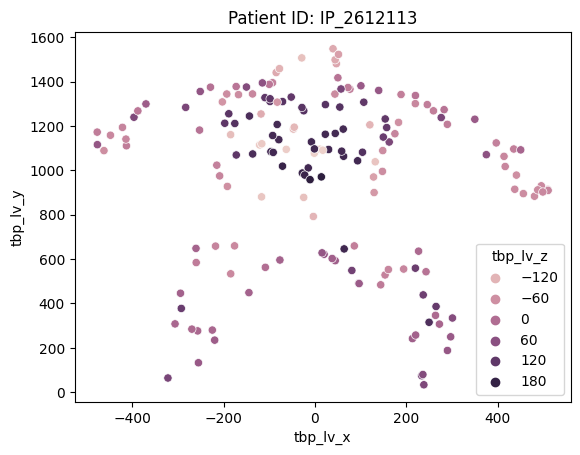

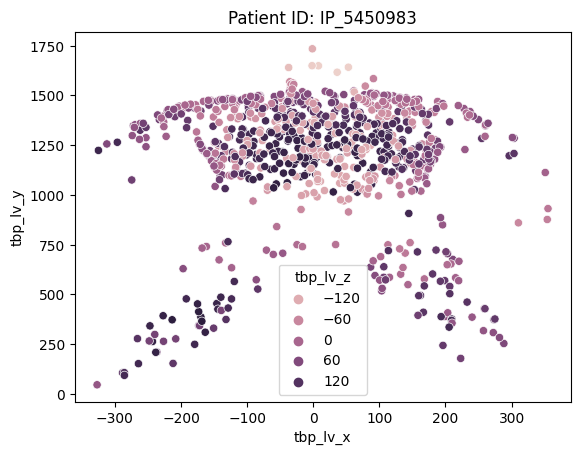

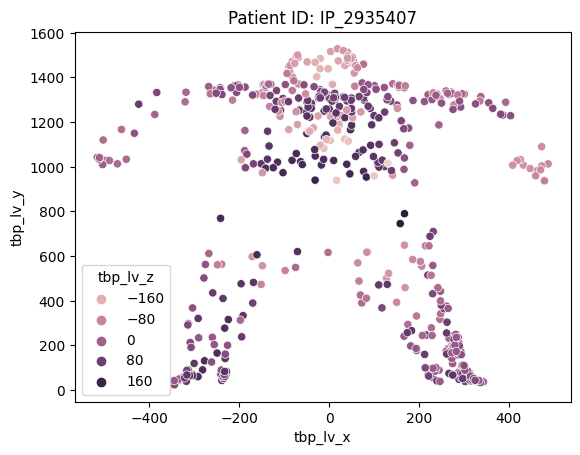

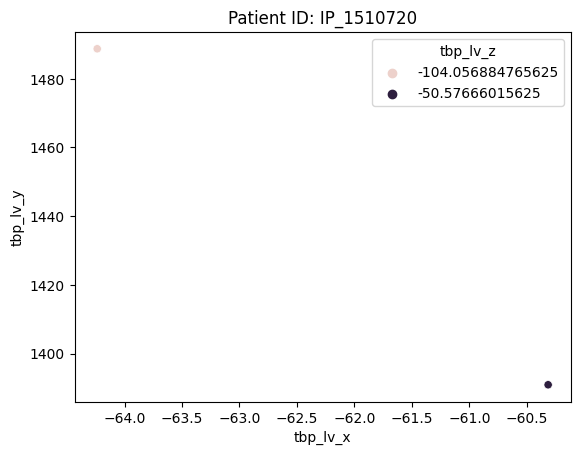

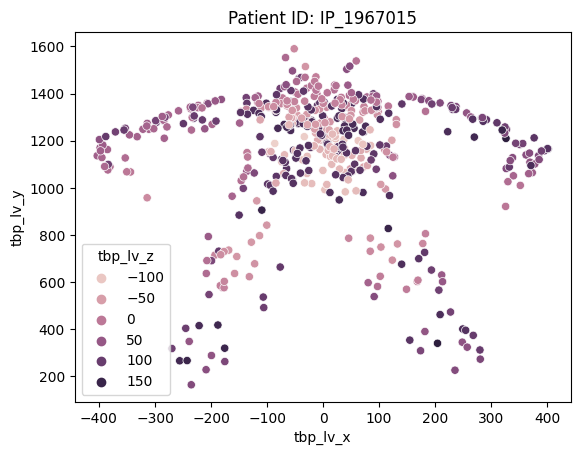

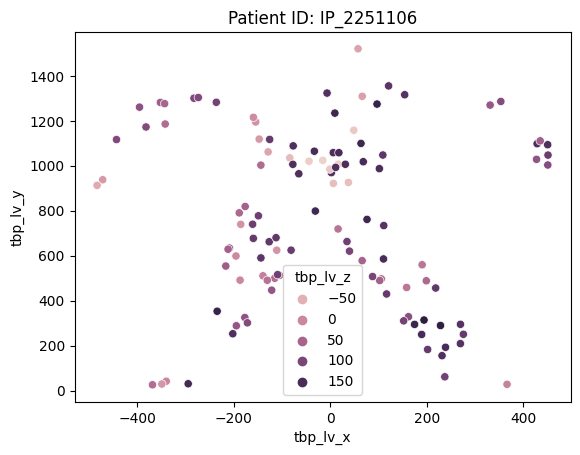

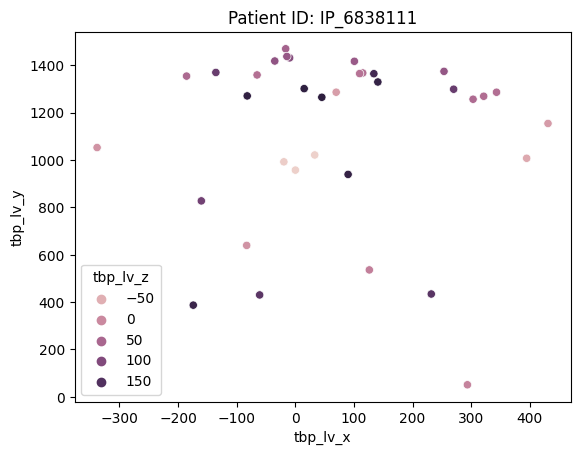

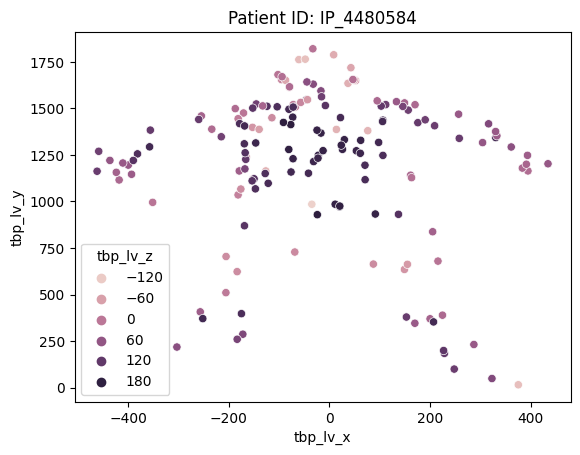

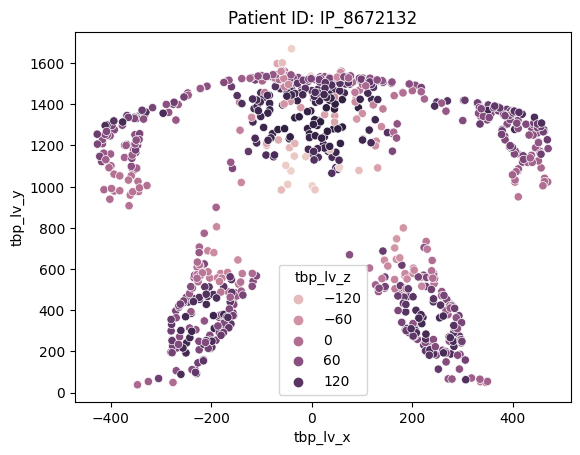

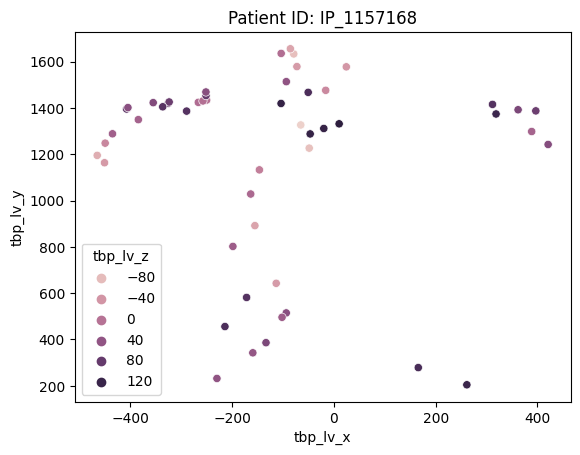

In [26]:
def plot_random_patient_coordinates_2d(df, num_patients=10):
  """
  Plots 2D scatter plots with color-coded z-value for randomly selected patients.

  Args:
    df: The DataFrame containing patient data.
    num_patients: The number of random patients to plot.
  """

  # Randomly select 'num_patients' number of unique patient IDs
  random_patients = df['patient_id'].drop_duplicates().sample(num_patients)

  for patient_id in random_patients:
    patient_data = df[df['patient_id'] == patient_id]
    sns.scatterplot(data=patient_data, x='tbp_lv_x', y='tbp_lv_y', hue='tbp_lv_z')
    plt.title(f'Patient ID: {patient_id}')
    plt.xlabel('tbp_lv_x')
    plt.ylabel('tbp_lv_y')
    plt.show()

# Example usage:
plot_random_patient_coordinates_2d(train_metadata, num_patients=10)

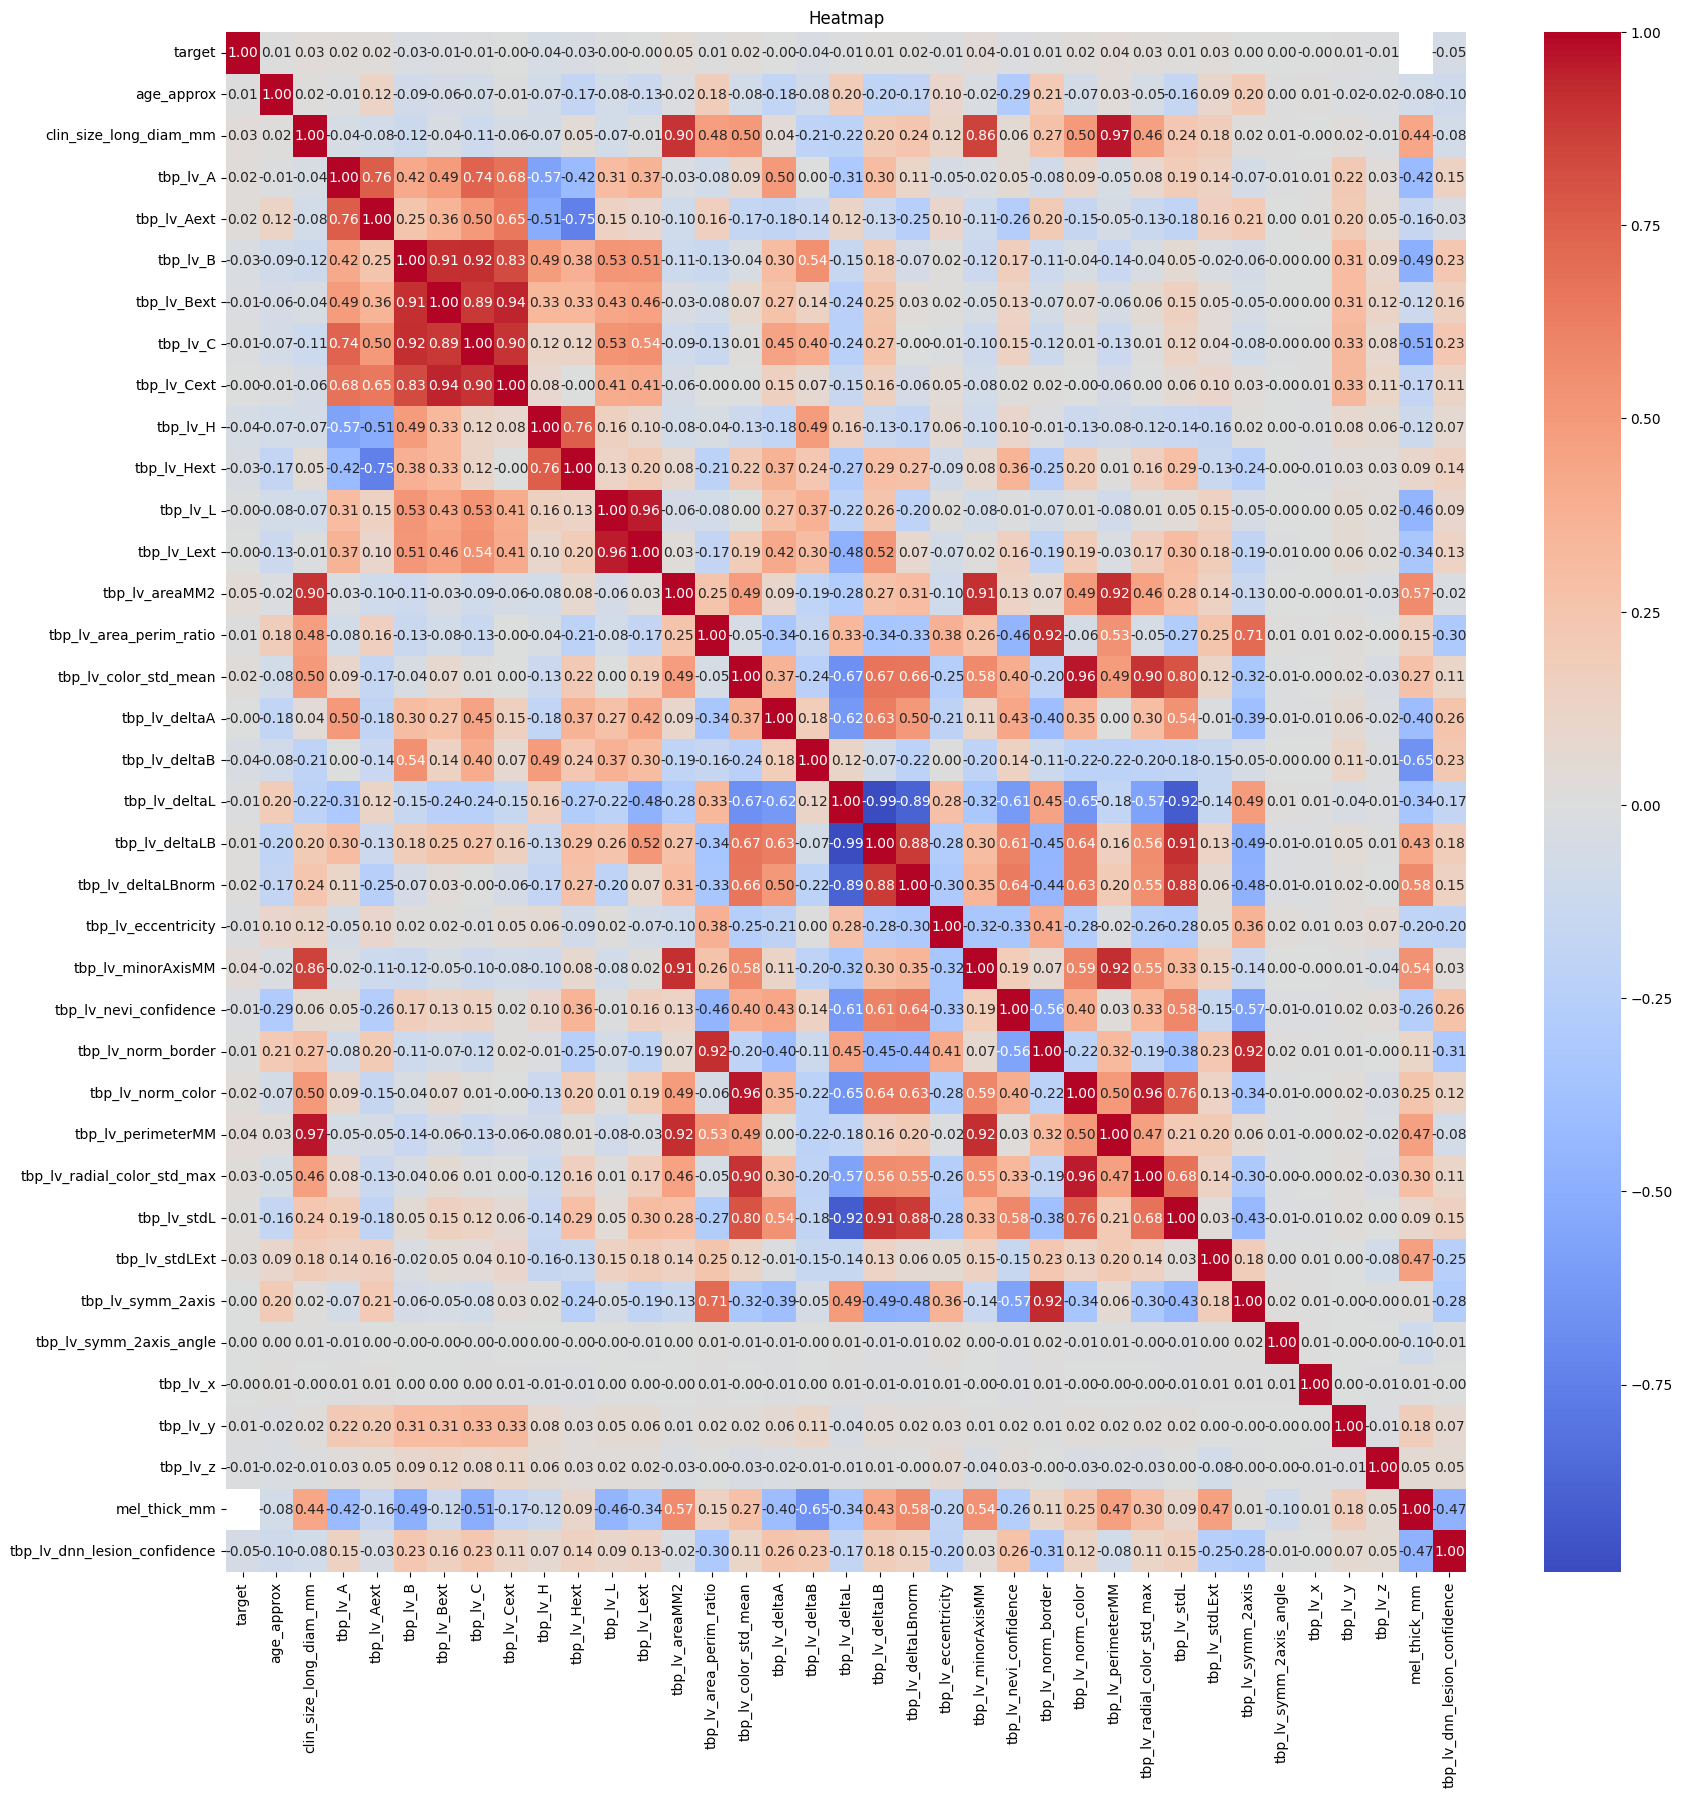

In [27]:
# 숫자형 컬럼을 사용하여 새로운 DataFrame 생성
numeric_data = train_metadata[numeric_col]

# 상관 행렬 계산
corr_matrix = numeric_data.corr()

# 히트맵 시각화
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', annot_kws={'size': 10}, cmap='coolwarm')
plt.title('Heatmap')
plt.show()

> **총정리:**  
> - 악성 종양 데이터가 전체의 0.1%정도로 매우 적다.  
> - 양성 종양과 큰 차이는 없지만 악성 종양 환자들이 조금 더 나이가 많은 경향이 있다.  
> - 성별에 따른 차이는 거의 없다.
> - 종양 위치가 head/neck일 경우 다른 위치의 종양보다 악성일 확률이 높다.
> - 종양이 클수록 악성일 확률이 높다.  
  
> **모델 학습에 필요 없는 컬럼:**  
> `isic_id`, `patient_id`, `attribution`, `copyright_license`  
  
> **인코딩 전략**  
> - **One-Hot Encoding**: `sex`, `anatom_site_general`, `image_type`, `tbp_tile_type`, `tbp_lv_location`, `tbp_lv_location_simple`  
>
> - **Label Encoding**: `iddx_full`, `iddx_1`, `iddx_2`, `iddx_3`, `iddx_4`, `iddx_5` 
  
> **이상치 처리 전략:**  
> 제거, 근접값으로 대체, 로그 변환 등